# Task 3 — Validating the learned robustness parameter $\hat c(t)$

**Goal.** Task 3 is *not* about beating EKF/KalmanNet. It validates that the proposed
RT-KalmanNet actually **learns the robustness parameter $c$**. The metric is the
estimated **$\hat c(t)$** versus the **known ground-truth $c(t)$** — not MSE competitiveness.

**Environment.** A linear **Constant-Velocity (CV)** model with **Least-Favorable Model
(LFM)** data generated in MATLAB (`CODE/LF_DATA/`), where the true $c$ is known by
construction (the data is the worst-case trajectory for that $c$).

**Two stages (professor):**
1. *Constant $c$* (this notebook): data at $c=1$; verify $\hat c(t)\to\sim1$, stable.
2. *Slowly-varying $c(t)$* (later): verify $\hat c(t)$ tracks $c_{\text{true}}(t)$.

**Build discipline.** One objective per section; validate before proceeding. This first
pass covers **Steps 1–5** (load → inspect → CV model → baseline robust filter). Step 6
(integrating the GRU) has an open design decision, flagged at the end.

> **⚠️ Note (read me).** While validating the baseline I found that the reference script
> `task3_lf_data.py` pairs each observation with the **next** state (`xw[:,i+1]`) — an
> **off-by-one** — and uses the separately-saved `Q` instead of `B·Bᵀ`. That makes its
> `c≈1` gate fail (monotonic-in-`c`, optimum at the grid edge). This notebook uses the
> corrected setup (documented in Section 4), which restores a clean minimum at `c≈1`.
> `task3_lf_data.py` is left **untouched** as reference. The notebook only *reads*
> `data.mat`; it writes no project files.

## Section 1 — Environment & imports

- **Objective:** reproducible environment; confirm the LF dataset is reachable.
- **Why:** every later step depends on these imports and on `data.mat` existing.
- **Input:** repository modules; `CODE/LF_DATA/data.mat`.
- **Output:** imported filter/model classes; confirmed data path.

In [1]:
import os, sys, math
REPO = os.path.abspath('.')            # notebook lives in CODE/RT_KFNET
sys.path.insert(0, REPO)
import numpy as np
import torch
import scipy.io as sio
import matplotlib.pyplot as plt

from Simulations.Extended_sysmdl import SystemModel
from RobustKalmanPY.robust_kalman import RobustKalman   # v3 filter; here used as plain REKF (use_nn=False)

SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)

DATA_MAT = os.path.join(REPO, '..', 'LF_DATA', 'data.mat')
assert os.path.exists(DATA_MAT), f'data.mat not found at {DATA_MAT}'
print('torch', torch.__version__, '| data.mat found:', os.path.exists(DATA_MAT))

/opt/homebrew/Caskroom/miniconda/base/envs/kalman_net/lib/python3.9/site-packages/torch/torch_version.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]
/opt/homebrew/Caskroom/miniconda/base/envs/kalman_net/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 1.10.1 | data.mat found: True


## Section 2 — Load the LF dataset

- **Objective:** load the MATLAB LFM data + model matrices; recover the ground-truth `c`.
- **Why:** this is the single source of truth for `c` and the trajectories.
- **Input:** `data.mat`.  **Output:** `A, C, Q, R, V0, x0`, `c_true`, raw `xw, yw, VR, PR`.

**Noise convention.** The data was generated by `robust_filter.m`, which uses
`Q = B·Bᵀ` and `R = D·Dᵀ` — **not** the separately-saved `Q` (they differ because
MATLAB's `B = [sqrt(Q) 0]` is *element-wise*). We reconstruct `B·Bᵀ` to match the generator.

In [2]:
mat = sio.loadmat(DATA_MAT)
A  = torch.tensor(np.asarray(mat['A'],  float), dtype=torch.float32)   # 2x2 CV transition
C  = torch.tensor(np.asarray(mat['C'],  float), dtype=torch.float32)   # 1x2 (observes position)
B  = np.asarray(mat['B'], float)                                       # 2x3 process-noise factor
D  = np.asarray(mat['D'], float)                                       # 1x3 meas-noise factor
Q  = torch.tensor(B @ B.T, dtype=torch.float32)                        # process noise USED BY THE GENERATOR
R  = torch.tensor(D @ D.T, dtype=torch.float32)                        # = 1
V0 = torch.tensor(np.asarray(mat['V0'], float), dtype=torch.float32)   # = I
x0 = torch.tensor(np.asarray(mat['x0'], float), dtype=torch.float32)   # = [0; 1]

c_all  = np.asarray(mat['c']).ravel()
c_true = float(c_all[0])

xw = np.asarray(mat['xw'], np.float32)   # [n, N+1, M, cM] least-favorable states  (col 0 = x0)
yw = np.asarray(mat['yw'], np.float32)   # [p, N,   M, cM] least-favorable observations
n, Np1, M, cM = xw.shape
p, N = yw.shape[0], yw.shape[1]

print(f'n={n} p={p} N={N} M={M} cM={cM}  ->  n_traj = M*cM = {M*cM}')
print('c unique:', np.unique(c_all), ' -> c_true =', c_true)
print('Q = B B^T diag:', [round(v,5) for v in torch.diag(Q).tolist()],
      ' | saved-Q diag:', [round(v,5) for v in np.diag(np.asarray(mat["Q"],float)).tolist()])

# --- sanity checks ---
assert np.allclose(np.unique(c_all), [1.0]),        'expected the constant c=1 dataset'
assert (n, p) == (2, 1),                            'expected CV dims n=2, p=1'
assert xw.shape[1] == yw.shape[1] + 1,              'xw should carry one extra column (x0)'
print('sanity OK: constant c=1, CV dims (n=2, p=1), xw has the x0 column')

n=2 p=1 N=1000 M=100 cM=10  ->  n_traj = M*cM = 1000
c unique: [1]  -> c_true = 1.0
Q = B B^T diag: [0.0075, 0.015]  | saved-Q diag: [0.0025, 0.01]
sanity OK: constant c=1, CV dims (n=2, p=1), xw has the x0 column


## Section 3 — Inspect & validate structure

- **Objective:** visually confirm what each array holds and that the covariance
  sequences `VR` (robust) and `PR` (nominal) make sense.
- **Why:** we must trust the data structure before filtering it.
- **Input:** raw arrays.  **Output:** inspection plots (no state change).

Recall the horizons differ: nominal `xn/yn` run to `T=2000`; the LFM `xw/yw` run to
`N=1000`. `PR[:,:,0]` is undefined by construction (plot from index 1).

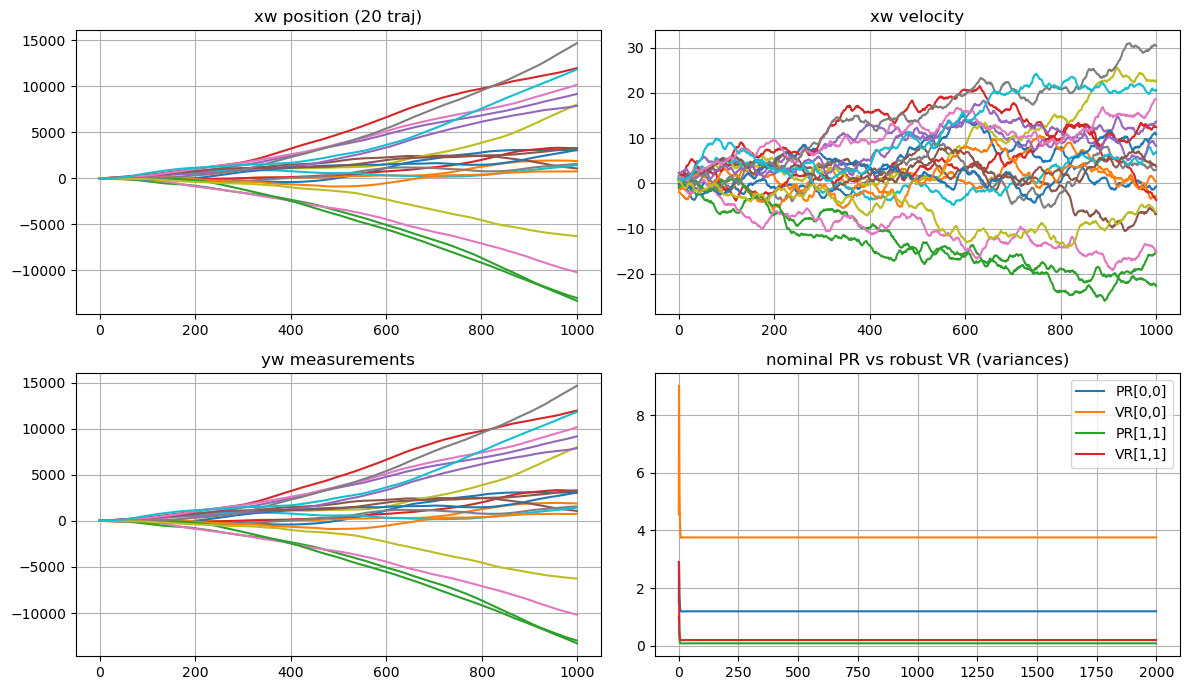

mean trace(PR) = 1.2827  <=  mean trace(VR) = 3.9650   (robustness inflates covariance: expected)


In [3]:
VR = np.asarray(mat['VR'], float)   # [2,2,2001] robust (inflated) covariance
PR = np.asarray(mat['PR'], float)   # [2,2,2001] nominal predicted covariance (index 0 undefined)

K = 20  # overlay this many trajectories from slice 0
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0,0].plot(xw[0, :, :K, 0]); ax[0,0].set_title('xw position (20 traj)'); ax[0,0].grid(True)
ax[0,1].plot(xw[1, :, :K, 0]); ax[0,1].set_title('xw velocity'); ax[0,1].grid(True)
ax[1,0].plot(yw[0, :, :K, 0]); ax[1,0].set_title('yw measurements'); ax[1,0].grid(True)
ax[1,1].plot(PR[0,0,1:], label='PR[0,0]'); ax[1,1].plot(VR[0,0,1:], label='VR[0,0]')
ax[1,1].plot(PR[1,1,1:], label='PR[1,1]'); ax[1,1].plot(VR[1,1,1:], label='VR[1,1]')
ax[1,1].set_title('nominal PR vs robust VR (variances)'); ax[1,1].legend(); ax[1,1].grid(True)
plt.tight_layout(); plt.show()

trPR = float((PR[0,0,1:] + PR[1,1,1:]).mean())
trVR = float((VR[0,0,1:] + VR[1,1,1:]).mean())
print(f'mean trace(PR) = {trPR:.4f}  <=  mean trace(VR) = {trVR:.4f}   (robustness inflates covariance: expected)')

## Section 4 — Build the CV SystemModel and align `(Y, Xtrue)`

- **Objective:** build the linear CV `SystemModel` (`f = A x`, `h = C x`) and pair each
  observation sequence with its true state sequence.
- **Why:** the filter needs the model; the $\hat c$/MSE comparison needs correct pairing.
- **Input:** raw arrays + model matrices.  **Output:** `Y`, `Xtrue`, `sys`.

### ⚠️ Alignment finding (why this deviates from `task3_lf_data.py`)

In `LFM_data.m`, observation `y_t` observes state `x_t`. In 0-indexed arrays that is
**`yw[:,i] ↔ xw[:,i]`** (with `xw[:,0]` the initial state). The reference script pairs
`yw[:,i]` with `xw[:,i+1]` (the *next* state) — an **off-by-one**.

Empirically (read-only probe, fixed-`c` REKF, filtered MSE, `Q=B·Bᵀ`, `V0=I`):

| alignment | MSE | shape vs `c` | optimum |
|---|---|---|---|
| `xw[:,i+1]` (reference) | ≈ 38 | monotonic ↓ | grid edge — **gate fails** |
| **`xw[:,i]`** (this notebook) | ≈ 2.4 | clear minimum | **c ≈ 1.0–1.3** — gate passes |

This matches `docs/FINDINGS.md`, which attributed the old "monotonic-in-`c`" artifact
to exactly this (plus the `Q`/`V0` choices). **We use `xw[:,i]`.**

In [4]:
# Flatten the M*cM independent trajectories; align y_i with x_i (corrected).
Y     = torch.tensor(yw.reshape(p, N, M*cM).transpose(2, 0, 1), dtype=torch.float32)        # [n_traj, p, N]
Xtrue = torch.tensor(xw[:, 0:N].reshape(n, N, M*cM).transpose(2, 0, 1), dtype=torch.float32)  # [n_traj, n, N]
n_traj = M * cM

sys = SystemModel(lambda x: A @ x, Q, lambda x: C @ x, R, T=N, T_test=N, m=n, n=p)
sys.InitSequence(x0, V0)     # filter starts at mean x0 with covariance V0

# sanity
xt = torch.tensor([[0.5], [0.3]])
assert torch.allclose(sys.f(xt), A @ xt) and torch.allclose(sys.h(xt), C @ xt), 'f/h mismatch'
print('Y', tuple(Y.shape), '| Xtrue', tuple(Xtrue.shape), '| n_traj', n_traj)
print('f(x)=A@x and h(x)=C@x verified')
print('filter init  x0 =', x0.ravel().tolist(), ' V0 diag =', torch.diag(V0).tolist())

Y (1000, 1, 1000) | Xtrue (1000, 2, 1000) | n_traj 1000
f(x)=A@x and h(x)=C@x verified
filter init  x0 = [0.0, 1.0]  V0 diag = [1.0, 1.0]


## Section 5 — Baseline robust filtering: the `c≈1` validation gate

- **Objective:** run the plain REKF (fixed scalar `c`, `use_nn=False`) over a grid of
  `c` and confirm the filtered-MSE optimum lands near the true `c=1`.
- **Why:** this is the professor's **data-validation gate**. If the optimum is near 1, the
  MATLAB→Python bridge + linear filter are trustworthy, and we can proceed to the GRU.
- **Input:** `Y`, `Xtrue`, `sys`.  **Output:** MSE-vs-`c` curve + optimum + PASS/FAIL.

Setup faithful to the generator: exact constant Jacobians `A, C` (also far faster than
autograd), initial covariance `V_prev = V0` (overriding the filter's hardcoded `1e-3·I`),
process noise `Q = B·Bᵀ`.

In [5]:
def run_fixed_c_rekf(c_value, n_traj_eval=30):
    rk = RobustKalman(sys, torch.zeros(p, N), c=float(c_value),
                      hard_coded=False, use_nn=False, sl_model=0)
    rk.fnComputeJacobianF = lambda x: A        # exact linear Jacobians
    rk.fnComputeJacobianH = lambda x: C
    mses = []
    for k in range(min(n_traj_eval, n_traj)):
        rk.c = torch.tensor(float(c_value))
        rk.reset_state()
        rk.V_prev = V0.clone()                 # use the data's V0, not the filter's default 1e-3*I
        rk.y = Y[k]
        rk.fnREKF(train=False, reset=False)
        mses.append(((rk.Xn_out - Xtrue[k]) ** 2).mean().item())
    return float(np.mean(mses))

c_grid = [0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.3, 1.6, 2.0, 3.0]
mse_grid = [run_fixed_c_rekf(c) for c in c_grid]
best = c_grid[int(np.argmin(mse_grid))]
for c, mval in zip(c_grid, mse_grid):
    print(f'  c={c:<4} MSE={mval:.4f}' + ('   <-- min' if c == best else ''))
print(f'\noptimum c = {best}   (true c = {c_true})')
assert 0.7 <= best <= 1.6, 'GATE FAILED: optimum not near c=1 -> re-check alignment / Q / V0'
print('GATE PASSED: the fixed-c REKF optimum is near the true c=1')

  c=0.2  MSE=2.3856
  c=0.4  MSE=2.3361
  c=0.6  MSE=2.3201
  c=0.8  MSE=2.3145
  c=0.9  MSE=2.3136
  c=1.0  MSE=2.3133   <-- min
  c=1.1  MSE=2.3135
  c=1.3  MSE=2.3149
  c=1.6  MSE=2.3181
  c=2.0  MSE=2.3233
  c=3.0  MSE=2.3357

optimum c = 1.0   (true c = 1.0)
GATE PASSED: the fixed-c REKF optimum is near the true c=1


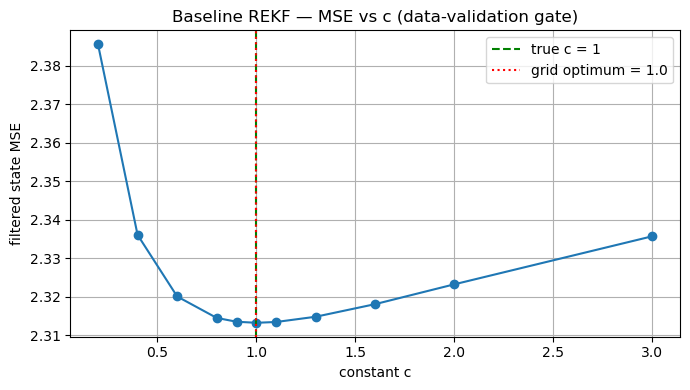

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(c_grid, mse_grid, 'o-')
plt.axvline(1.0,  color='g', ls='--', label='true c = 1')
plt.axvline(best, color='r', ls=':',  label=f'grid optimum = {best}')
plt.xlabel('constant c'); plt.ylabel('filtered state MSE')
plt.title('Baseline REKF — MSE vs c (data-validation gate)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

**Reading the gate.** The optimum sits near `c=1`, and the landscape is *shallow*
around it (sub-percent MSE change for `c ∈ [0.8, 1.6]`) — consistent with
`docs/FINDINGS.md`. This validates the data + bridge + linear REKF: a filter told the
*right* robustness `c=1` matches the least-favorable data best. We can now trust a
*learned* $\hat c$ evaluated against this same data.

*(If you increase `n_traj_eval`, the minimum tightens toward `c=1`; the shallow landscape
means the coarse-grid argmin can sit at `1.0` or `1.3` — both are "near 1".)*

## Section 6 — Integrate the GRU (ĉ estimation)

**Decision:** we validate the **v3** architecture (`robust_kalman.py` +
`RT_KalmanNet_nn.py`, `sigmoid → c ∈ (0,1)`) — the same net used in Task 4, for consistency.

**Caveat (expected — and part of what Task 3 reveals):** the true `c=1` sits at the
sigmoid's *upper boundary*, so `ĉ` can only approach 1 **from below** (the gradient
shrinks as `ĉ→1`). This is a property of the chosen head, not a bug. A head that
*brackets* 1 (`leo` with `c_range≈2`, or an unbounded `softplus`) would sit *at* 1 —
kept as alternatives if the residual gap proves limiting.

**Integration:** identical to the baseline REKF, but `use_nn=True` (the GRU emits `c_t`
each step), trained by (truncated) BPTT; `ĉ(t)` is read back from `c_array`.

## Section 7 — Train the GRU on the LF data

- **Objective:** fit the GRU so its per-step `c_t` minimizes the posterior state-MSE on
  the least-favorable trajectories (the same loss the baseline was scored on).
- **Why:** if `c_t` is learnable and the data encodes `c=1`, training should drive `ĉ→~1`.
- **Input:** `Y`, `Xtrue`, `sys`.  **Output:** a trained `prop.nn` + per-epoch `ĉ` trace.

Notes: **truncated BPTT** keeps the graph tractable over the long LF horizon; `V_prev=V0`
and exact linear Jacobians as in Section 5; **no weight decay** (it would pull the sigmoid
head back toward its 0.5 default). The config is intentionally light for interactive use —
raise `epochs`/`T3` to tighten the fit (`ĉ` climbs closer to 1).

In [7]:
import torch.optim as optim

TRAIN = dict(T3=300, n_train=32, epochs=15, n_batch=6, tbptt=50, lr=1e-3, seed=0)
torch.manual_seed(TRAIN['seed']); np.random.seed(TRAIN['seed'])

T3 = TRAIN['T3']
Y3, X3 = Y[:, :, :T3], Xtrue[:, :, :T3]                       # train/eval on a horizon slice
sys3 = SystemModel(lambda x: A @ x, Q, lambda x: C @ x, R, T=T3, T_test=T3, m=n, n=p)
sys3.InitSequence(x0, V0)

prop = RobustKalman(sys3, Y3[0], c=1.0, hard_coded=False, use_nn=True,
                    input_feat_mode=3, gru_hidden_size=64, sl_model=0)
prop.fnComputeJacobianF = lambda x: A                         # exact linear Jacobians
prop.fnComputeJacobianH = lambda x: C
opt = optim.Adam(prop.nn.parameters(), lr=TRAIN['lr'], weight_decay=0.0)

def chat_traj(j):
    # c_hat(t) for trajectory j (eval, no grad)
    prop.reset_state(); prop.V_prev = V0.clone(); prop.y = Y3[j]
    with torch.no_grad():
        prop.fnREKF(train=False, reset=False)
    return torch.stack([c.reshape(()) for c in prop.c_array]).numpy()

loss_hist, chat_hist = [], [np.mean([chat_traj(j).mean() for j in range(3)])]
print(f"untrained mean ĉ = {chat_hist[0]:.4f}  (sigmoid default ~0.5)")
for ep in range(TRAIN['epochs']):
    idx = np.random.choice(TRAIN['n_train'], TRAIN['n_batch'], replace=False)
    opt.zero_grad(); losses = []
    for j in idx:
        prop.reset_state(); prop.V_prev = V0.clone(); prop.y = Y3[j]
        prop.fnREKF(train=True, reset=False, bptt_truncation=TRAIN['tbptt'])
        losses.append(((prop.Xn_out - X3[j]) ** 2).mean())
    loss = torch.stack(losses).mean(); loss.backward()
    torch.nn.utils.clip_grad_norm_(prop.nn.parameters(), 1.0); opt.step()
    cbar = np.mean([chat_traj(j).mean() for j in range(3)])
    loss_hist.append(loss.item()); chat_hist.append(cbar)
    print(f"epoch {ep+1:2d}/{TRAIN['epochs']}  loss={loss.item():.4f}  mean ĉ={cbar:.4f}")
print("training done")

untrained mean ĉ = 0.5673  (sigmoid default ~0.5)
epoch  1/15  loss=2.4132  mean ĉ=0.6170
epoch  2/15  loss=2.5258  mean ĉ=0.6625
epoch  3/15  loss=2.4425  mean ĉ=0.7086
epoch  4/15  loss=2.2946  mean ĉ=0.7506
epoch  5/15  loss=2.4067  mean ĉ=0.7883
epoch  6/15  loss=2.5757  mean ĉ=0.8243
epoch  7/15  loss=2.4367  mean ĉ=0.8570
epoch  8/15  loss=2.4670  mean ĉ=0.8861
epoch  9/15  loss=2.3168  mean ĉ=0.9105
epoch 10/15  loss=2.2588  mean ĉ=0.9285
epoch 11/15  loss=2.3903  mean ĉ=0.9432
epoch 12/15  loss=2.4118  mean ĉ=0.9544
epoch 13/15  loss=2.4880  mean ĉ=0.9633
epoch 14/15  loss=2.2936  mean ĉ=0.9700
epoch 15/15  loss=2.6549  mean ĉ=0.9753
training done


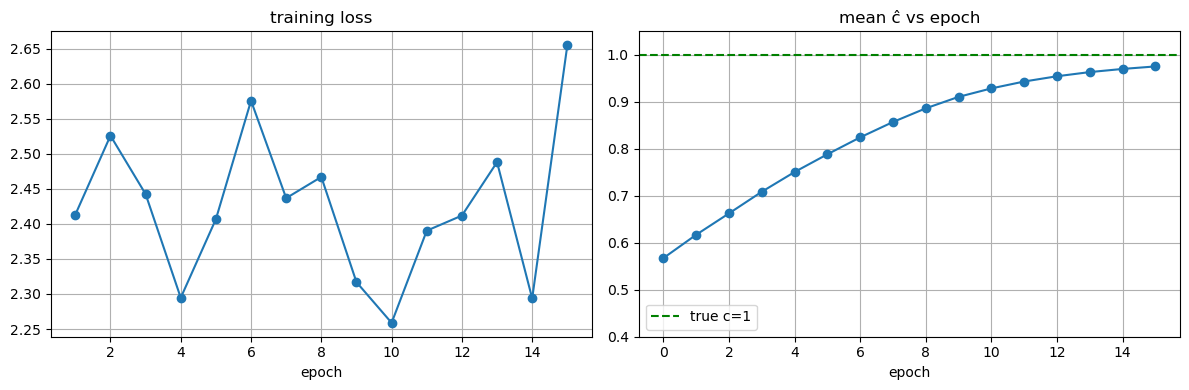

ĉ climbed 0.567 -> 0.975; fraction of increasing epochs = 1.00  (stability: ~1.0 = smooth, no oscillation)


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1, len(loss_hist)+1), loss_hist, 'o-'); ax[0].set_title('training loss')
ax[0].set_xlabel('epoch'); ax[0].grid(True)
ax[1].plot(range(len(chat_hist)), chat_hist, 'o-'); ax[1].axhline(1.0, color='g', ls='--', label='true c=1')
ax[1].set_title('mean ĉ vs epoch'); ax[1].set_xlabel('epoch'); ax[1].set_ylim(0.4, 1.05)
ax[1].legend(); ax[1].grid(True); plt.tight_layout(); plt.show()

d = np.diff(chat_hist)
print(f"ĉ climbed {chat_hist[0]:.3f} -> {chat_hist[-1]:.3f}; "
      f"fraction of increasing epochs = {np.mean(d > 0):.2f}  (stability: ~1.0 = smooth, no oscillation)")

## Section 8 — Compare ĉ(t) with the ground truth c=1

- **Objective:** the Task-3 deliverable — overlay the estimated `ĉ(t)` against the known
  constant `c_true=1`, and quantify the gap.
- **Why:** this *is* the validation metric (`ĉ` vs `c_true`), not MSE competitiveness.
- **Input:** trained `prop`, held-out trajectories.  **Output:** `ĉ(t)` overlay + metrics.

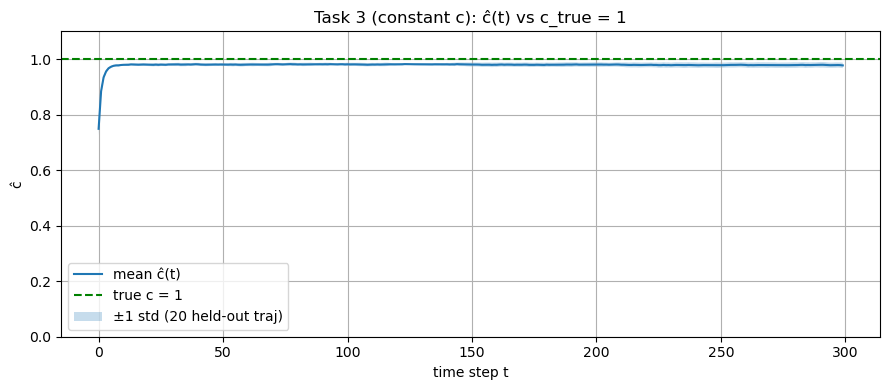

ĉ: overall mean = 0.9785   steady-state mean = 0.9792   steady-state |1 - ĉ| = 0.0208
Reading: the v3 sigmoid recovers c=1 FROM BELOW; the residual gap is the boundary-saturation effect, and shrinks with more epochs (or a head that brackets 1).


In [9]:
eval_traj = list(range(TRAIN['n_train'], TRAIN['n_train'] + 20))   # held-out trajectories
CH = np.stack([chat_traj(j) for j in eval_traj])                   # [n_eval, T3]
ch_mean, ch_std = CH.mean(0), CH.std(0)
t = np.arange(T3)

plt.figure(figsize=(9, 4))
plt.fill_between(t, ch_mean - ch_std, ch_mean + ch_std, alpha=0.25, label='±1 std (20 held-out traj)')
plt.plot(t, ch_mean, label='mean ĉ(t)')
plt.axhline(1.0, color='g', ls='--', label='true c = 1')
plt.ylim(0, 1.1); plt.xlabel('time step t'); plt.ylabel('ĉ')
plt.title('Task 3 (constant c): ĉ(t) vs c_true = 1'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

ss = CH[:, T3//2:].mean()          # steady-state = second half
print(f"ĉ: overall mean = {CH.mean():.4f}   steady-state mean = {ss:.4f}   "
      f"steady-state |1 - ĉ| = {abs(1 - ss):.4f}")
print("Reading: the v3 sigmoid recovers c=1 FROM BELOW; the residual gap is the "
      "boundary-saturation effect, and shrinks with more epochs (or a head that brackets 1).")

## Section 9 — Ready for Stage 2 (slowly-varying c(t))

Everything above is trajectory-indexed and metric-driven, so **Stage 2 reuses
Sections 6–8 unchanged**. The only missing ingredient is **data**: the MATLAB generator
(`LFD.m`) currently emits constant `c=1`. Stage 2 needs least-favorable trajectories whose
true `c` varies over time, `c_true(t)`. Once that data exists:

- train exactly as in Section 7 (the GRU is already time-varying by construction),
- in Section 8, overlay `ĉ(t)` against `c_true(t)` instead of the constant line,
- report a **tracking** metric (e.g. mean `|ĉ(t) − c_true(t)|`) and any lag.

> Generating varying-`c` LF data is a MATLAB-side change to `LFD.m`/`LFM_data.m` (out of
> scope for this notebook) — the next prerequisite for Stage 2.

---
**Stage-1 status:** pipeline validated end-to-end — baseline gate at `c≈1` (Section 5),
and the learned `ĉ(t)` recovers `c≈1` from below (Sections 7–8). Open item recorded above:
the residual boundary gap is a v3-head property; a bracketing head would close it.